<a href="https://colab.research.google.com/github/jgybels/CEE-593---Module-4/blob/main/Module_4_Sounding_Refinement_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Geology 593 - Engineering Geology
# Module 4 - Cleaning and Visualizing Site Investigation Data

In [ ]:
#Import Python Libraries
!pip install pandas openpyxl xlrd

import pandas as pd
import numpy as np
from pathlib import Path

In [ ]:
# Import XLS files
from google.colab import files
uploaded = files.upload()

Saving 24-61-27761_SP24-COOK-07-BSC.XLS to 24-61-27761_SP24-COOK-07-BSC.XLS
Saving 24-61-27761_SP24-COOK-02-OFF01-BSC.XLS to 24-61-27761_SP24-COOK-02-OFF01-BSC.XLS
Saving 24-61-27761_CP24-COOK-06-OFF01-BSC.XLS to 24-61-27761_CP24-COOK-06-OFF01-BSC.XLS
Saving 24-61-27761_CP24-COOK-06-BSC.XLS to 24-61-27761_CP24-COOK-06-BSC.XLS
Saving 24-61-27761_CP24-COOK-04-BSC.XLS to 24-61-27761_CP24-COOK-04-BSC.XLS
Saving 24-61-27761_CP24-COOK-03-BSC.XLS to 24-61-27761_CP24-COOK-03-BSC.XLS
Saving 24-61-27761_SP24-COOK-02-OFF02-BSC.XLS to 24-61-27761_SP24-COOK-02-OFF02-BSC.XLS
Saving 24-61-27761_SP24-COOK-02-BSC.XLS to 24-61-27761_SP24-COOK-02-BSC.XLS
Saving 24-61-27761_CP24-COOK-01-BSC.XLS to 24-61-27761_CP24-COOK-01-BSC.XLS


In [ ]:
# Inpect the workbook
path = "24-61-27761_CP24-COOK-01-BSC.XLS"

# See available sheet names (if multiple)
xl = pd.ExcelFile(path, engine="xlrd")
print(xl.sheet_names)

# Peek at the top of the sheet (often metadata)
preview = pd.read_excel(path, sheet_name=0, nrows=30, header=None, engine="xlrd")
print(preview)


['Sheet1']
     0                                                  1   2   3  \
0  NaN                  ConeTec Calculated CPT Parameters NaN NaN   
1  NaN  Calculated CPT Parameters Output - SCREENzW Ve... NaN NaN   
2  NaN                                 DAS Version: CS162 NaN NaN   
3  NaN                             Interpretation Format: NaN NaN   
4  NaN                                            Run ID: NaN NaN   
5  NaN                                            Job No: NaN NaN   
6  NaN                                            Client: NaN NaN   
7  NaN                                           Project: NaN NaN   
8  NaN                                          Facility: NaN NaN   
9  NaN                                       Sounding ID: NaN NaN   
10 NaN                                           Cone ID: NaN NaN   
11 NaN                                          Operator: NaN NaN   
12 NaN                                          CPT Date: NaN NaN   
13 NaN                 

In [ ]:
# Getting the data table
def find_header_row(path, sheet_name=0, search_text="Depth", max_rows=120):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None, nrows=max_rows)
    mask = raw.apply(
        lambda row: row.astype(str).str.contains(search_text, case=False, na=False).any(),
        axis=1
    )
    hits = raw.index[mask].tolist()
    return hits[0] if hits else None

header_row = find_header_row(path, sheet_name=0, search_text="Depth")
print("Detected header row:", header_row)

df = pd.read_excel(path, sheet_name=0, skiprows=header_row, header=0)
print(df.columns)
print(df.head())


Detected header row: 38
Index(['Layer', 'Depth', 'Depth.1', 'qc', 'qt', 'fs', 'u', 'Rf'], dtype='object')
   Layer  Depth  Depth.1      qc         qt     fs      u          Rf
0    NaN      m       ft     tsf        tsf    tsf     ft           %
1    1.0  0.025  0.08202   0.036    0.03673  0.038  0.117  103.456543
2    2.0   0.05  0.16404  21.657  21.678931   0.08  3.513    0.369022
3    3.0  0.075  0.24606  41.663  41.696486  0.097  5.364    0.232634
4    4.0    0.1  0.32808  64.817  64.861517  0.201  7.131    0.309891


In [ ]:
# Cleaning and Standardizing CPT Data in pandas

# Clean columns names
df.columns = [str(c).strip() for c in df.columns]

# Rename columns to standard names
rename_map = {
    "Depth": "depth_m",
    "Depth.1": "depth_ft",
    "qc": "qc_tsf",
    "qt": "qt_tsf",
    "fs": "fs_tsf",
    "u": "u_tsf",
    "Rf": "rf_pct"
}
df = df.rename(columns=rename_map)
print(df.rename)

# Convert numeric columns into real numbers
num_cols = ["depth_ft", "depth_m", "qc_tsf", "qt_tsf", "fs_tsf", "u_tsf", "rf_pct"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows with no detph
if "depth_ft" in df.columns:
    df = df.dropna(subset=["depth_ft"])

# Drop empty rows
df = df.dropna(how="all")

# Add sounding ID
sounding_id = "CPT24-cook-01"
df["sounding_id"] = sounding_id

# Sort by depth
print(df.columns)
depth_col = "depth_ft" if "depth_ft" in df.columns else "depth_m"
df = df.sort_values(depth_col).reset_index(drop=True)

# Sort by depth to ensure consistent plotting/analysis
depth_col = "depth_ft" if "depth_ft" in df.columns else "depth_m"
df = df.sort_values(depth_col).reset_index(drop=True)

# Quick checks
print("Min depth:", df[depth_col].min(), "Max depth:", df[depth_col].max())
print("Has duplicates?", df[depth_col].duplicated().any())

# Negative sleeve friction is suspicious; flag it
if "fs_tsf" in df.columns:
    df["fs_negative_flag"] = df["fs_tsf"] < 0

# Friction ratio should not be negative; set negatives to NaN
if "rf_pct" in df.columns:
    df.loc[df["rf_pct"] < 0, "rf_pct"] = pd.NA

# Only compute if you have both columns and qc is nonzero
if ("fs_tsf" in df.columns) and ("qc_tsf" in df.columns):
    df["rf_pct_calc"] = (df["fs_tsf"] / df["qc_tsf"]) * 100
    df.loc[df["qc_tsf"] == 0, "rf_pct_calc"] = pd.NA





<bound method DataFrame.rename of     Layer depth_m depth_ft   qc_tsf      qt_tsf fs_tsf  u_tsf    rf_pct  \
0     NaN       m       ft      tsf         tsf    tsf     ft         %   
1     1.0   0.025  0.08202   13.162   13.162893  0.159  0.143  1.207941   
2     2.0    0.05  0.16404    41.11    41.11545  0.758  0.873  1.843589   
3     3.0   0.075  0.24606   50.933    50.94724  1.032  2.281  2.025625   
4     4.0     0.1  0.32808   55.949   55.970157  1.271  3.389  2.270853   
5     5.0   0.125   0.4101   66.339   66.368135  1.897  4.667  2.858299   
6     6.0    0.15  0.49212   93.819   93.853141  1.899  5.469  2.023374   
7     7.0   0.175  0.57414  190.315  190.359311  1.979  7.098  1.039613   
8     8.0     0.2  0.65616  216.572  216.619932  1.834  7.678  0.846644   
9     9.0   0.225  0.73818  145.748  145.793122  1.781  7.228  1.221594   
10   10.0    0.25   0.8202  126.497  126.541192  2.461  7.079  1.944821   
11   11.0   0.275  0.90222       65   65.049642  3.669  7.952  5.6

In [ ]:
# Combining Mutiple soundings into one dataset
data_dir = Path("data/raw")

file_map = {
    "CPT24-cook-01": "24-61-27761_CP24-COOK-01-BSC.XLS",
    "CPT24-cook-02": "24-61-27761_SP24-COOK-02-BSC.XLS",
    "CPT24-cook-02-OFF01": "24-61-27761_SP24-COOK-02-OFF01-BSC.XLS",
    "CPT24-cook-02-OFF02": "24-61-27761_SP24-COOK-02-OFF02-BSC.XLS",
    "CPT24-cook-03": "24-61-27761_CP24-COOK-03-BSC.XLS",
    "CPT24-cook-04": "24-61-27761_CP24-COOK-04-BSC.XLS",
    "CPT24-cook-06": "24-61-27761_CP24-COOK-06-BSC.XLS",
    "CPT24-cook-07": "24-61-27761_SP24-COOK-07-BSC.XLS",
    "CPT24-cook-06-OFF01": "24-61-27761_CP24-COOK-06-OFF01-BSC.XLS"
}

all_soundings = []

for sid, fname in file_map.items():
  path = data_dir / fname
  df = pd.read_excel(fname, sheet_name=0, skiprows=39, header=0, engine="xlrd")
  df.columns = [str(c).strip() for c in df.columns]
  df["Sounding"] = sid
  df = df.rename(columns={
        "depth (ft)": "depth_ft",
        "qt (tsf)": "qt_tsf",
        "fs (tsf)": "fs_tsf"
    })

  for c in ["depth_ft", "qt_tsf", "fs_tsf"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

  # Drop non data rows
  if "depth_ft" in df.columns:
        df = df.dropna(subset=["depth_ft"])

  df["Sounding"] = sid

  all_soundings.append(df)

cpt_all = pd.concat(all_soundings, ignore_index=True)

#Print Summary Table to  Perform a Quick-Check
sounding_summary = cpt_all.groupby('Sounding')['ft'].max().reset_index()
sounding_summary['ft'] = sounding_summary['ft'].round(2)
sounding_summary.rename(columns={'ft': 'Expected Final Depth (ft)'}, inplace=True)
print(sounding_summary)


              Sounding  Expected Final Depth (ft)
0        CPT24-cook-01                      37.16
1        CPT24-cook-02                       3.20
2  CPT24-cook-02-OFF01                       2.13
3  CPT24-cook-02-OFF02                       3.44
4        CPT24-cook-03                      51.02
5        CPT24-cook-04                      51.10
6        CPT24-cook-06                       9.60
7  CPT24-cook-06-OFF01                       3.03
8        CPT24-cook-07                      62.75


In [ ]:
# Saving Cleaned Data & Import

# Create folder
Path("data/processed").mkdir(parents=True, exist_ok=True)

# Save CSV
cpt_all.to_csv("data/processed/cpt_clean.csv", index=False)

# Import
from google.colab import files
files.download("data/processed/cpt_clean.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

STEP X - PROMPT A CODE FOR LATER RETURN OF CLEANED CPT DATA

Please upload your cleaned CSV file:


Saving cpt_clean.csv to cpt_clean.csv


In [ ]:
import pandas as pd

# Load the cleaned CSV file
# Assuming 'cpt_clean.csv' is in the current directory, as it was downloaded previously
df_cleaned = pd.read_csv("cpt_clean.csv")

# Define the mapping from existing column names to the new names provided by the user
# Columns not in this map will remain unchanged.
rename_map = {
    'Unnamed: 0': '---',
    'm': 'Depth.m',
    'ft': 'Depth.ft',
    'tsf': 'q_c.tsf',
    'tsf.1': 'q_t.tsf',
    'tsf.2': 'f_s.tsf',
    'ft.1': 'u.ft',
    '%': 'Rf.%'
}

# Apply the renaming
df_cleaned = df_cleaned.rename(columns=rename_map)

# Remove the first 2 columns as requested by the user
df_cleaned = df_cleaned.drop(columns=['---'])

# Display the first few rows with the new column headers
print("DataFrame with updated column headers:")
print(df_cleaned.head())

DataFrame with updated column headers:
   Depth.m  Depth.ft  q_c.tsf    q_t.tsf  f_s.tsf   u.ft        Rf.%  \
0    0.025   0.08202    0.036   0.036730    0.038  0.117  103.456543   
1    0.050   0.16404   21.657  21.678931    0.080  3.513    0.369022   
2    0.075   0.24606   41.663  41.696486    0.097  5.364    0.232634   
3    0.100   0.32808   64.817  64.861517    0.201  7.131    0.309891   
4    0.125   0.41010   82.667  82.724046    0.490  9.138    0.592331   

        Sounding  
0  CPT24-cook-01  
1  CPT24-cook-01  
2  CPT24-cook-01  
3  CPT24-cook-01  
4  CPT24-cook-01  


In [ ]:
preferred_units = input("Please enter your preferred units (type 'meter' or 'imperial'): ").lower()
print(f"You selected: {preferred_units}")


Please enter your preferred units (type 'meter' or 'imperial'): imperial
You selected: imperial


In [ ]:
# Get the index of the 'Sounding' column
sounding_col_index = df_cleaned.columns.get_loc('Sounding')

# Insert new columns before the 'Sounding' column in reverse order
# so they appear in the desired order (Q_T, F_r, I_c, Q_change)
df_cleaned.insert(loc=sounding_col_index, column='unit weight', value=pd.NA)
df_cleaned.insert(loc=sounding_col_index, column='Q_change', value=pd.NA)
df_cleaned.insert(loc=sounding_col_index, column='I_c', value=pd.NA)
df_cleaned.insert(loc=sounding_col_index, column='F_r', value=pd.NA)
df_cleaned.insert(loc=sounding_col_index, column='Q_T', value=pd.NA)


ValueError: cannot insert Q_change, already exists

In [ ]:
# Display the head of the DataFrame to show the new columns
print("DataFrame with new columns inserted:")
print(df_cleaned.head())

# Display information about the DataFrame to see the new columns and their data types
print("\nDataFrame Info:")
df_cleaned.info()

DataFrame with new columns inserted:
   Depth.m  Depth.ft  q_c.tsf    q_t.tsf  f_s.tsf   u.ft        Rf.%   Q_T  \
0    0.025   0.08202    0.036   0.036730    0.038  0.117  103.456543  <NA>   
1    0.050   0.16404   21.657  21.678931    0.080  3.513    0.369022  <NA>   
2    0.075   0.24606   41.663  41.696486    0.097  5.364    0.232634  <NA>   
3    0.100   0.32808   64.817  64.861517    0.201  7.131    0.309891  <NA>   
4    0.125   0.41010   82.667  82.724046    0.490  9.138    0.592331  <NA>   

    F_r   I_c Q_change unit weight       Sounding  
0  <NA>  <NA>     <NA>        <NA>  CPT24-cook-01  
1  <NA>  <NA>     <NA>        <NA>  CPT24-cook-01  
2  <NA>  <NA>     <NA>        <NA>  CPT24-cook-01  
3  <NA>  <NA>     <NA>        <NA>  CPT24-cook-01  
4  <NA>  <NA>     <NA>        <NA>  CPT24-cook-01  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2724 entries, 0 to 2723
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------     

In [ ]:
import pandas as pd

# Get unique sounding IDs from the DataFrame
available_soundings = df_cleaned['Sounding'].unique()

print("Available Soundings for Analysis:")
for i, sounding_id in enumerate(available_soundings):
    print(f"{i+1}. {sounding_id}")

# Ask the user to select soundings
selection_input = input("Enter the numbers of the soundings you want to analyze, separated by commas (e.g., 1,3,5): ")

# Process the user's input
selected_indices = []
try:
    selected_indices_str = selection_input.split(',')
    for s_idx_str in selected_indices_str:
        s_idx = int(s_idx_str.strip()) - 1  # Convert to 0-based index
        if 0 <= s_idx < len(available_soundings):
            selected_indices.append(s_idx)
        else:
            print(f"Warning: Invalid sounding number '{s_idx_str.strip()}' ignored.")
except ValueError:
    print("Invalid input format. Please enter numbers separated by commas.")
    selected_soundings = []

selected_soundings = [available_soundings[i] for i in selected_indices]

if selected_soundings:
    print(f"You have selected the following soundings for analysis: {', '.join(selected_soundings)}")
    # Optionally filter the DataFrame based on selected soundings
    df_selected = df_cleaned[df_cleaned['Sounding'].isin(selected_soundings)].copy()
    print("DataFrame filtered with selected soundings:")
    print(df_selected.head())
else:
    print("No valid soundings were selected.")


Available Soundings for Analysis:
1. CPT24-cook-01
2. CPT24-cook-02
3. CPT24-cook-02-OFF01
4. CPT24-cook-02-OFF02
5. CPT24-cook-03
6. CPT24-cook-04
7. CPT24-cook-06
8. CPT24-cook-07
9. CPT24-cook-06-OFF01
Enter the numbers of the soundings you want to analyze, separated by commas (e.g., 1,3,5): 1,2,3,4,5,6,7,8,9
You have selected the following soundings for analysis: CPT24-cook-01, CPT24-cook-02, CPT24-cook-02-OFF01, CPT24-cook-02-OFF02, CPT24-cook-03, CPT24-cook-04, CPT24-cook-06, CPT24-cook-07, CPT24-cook-06-OFF01
DataFrame filtered with selected soundings:
   Depth.m  Depth.ft  q_c.tsf    q_t.tsf  f_s.tsf   u.ft        Rf.%   Q_T  \
0    0.025   0.08202    0.036   0.036730    0.038  0.117  103.456543  <NA>   
1    0.050   0.16404   21.657  21.678931    0.080  3.513    0.369022  <NA>   
2    0.075   0.24606   41.663  41.696486    0.097  5.364    0.232634  <NA>   
3    0.100   0.32808   64.817  64.861517    0.201  7.131    0.309891  <NA>   
4    0.125   0.41010   82.667  82.724046    

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("matplotlib.pyplot and seaborn imported successfully.")

matplotlib.pyplot and seaborn imported successfully.


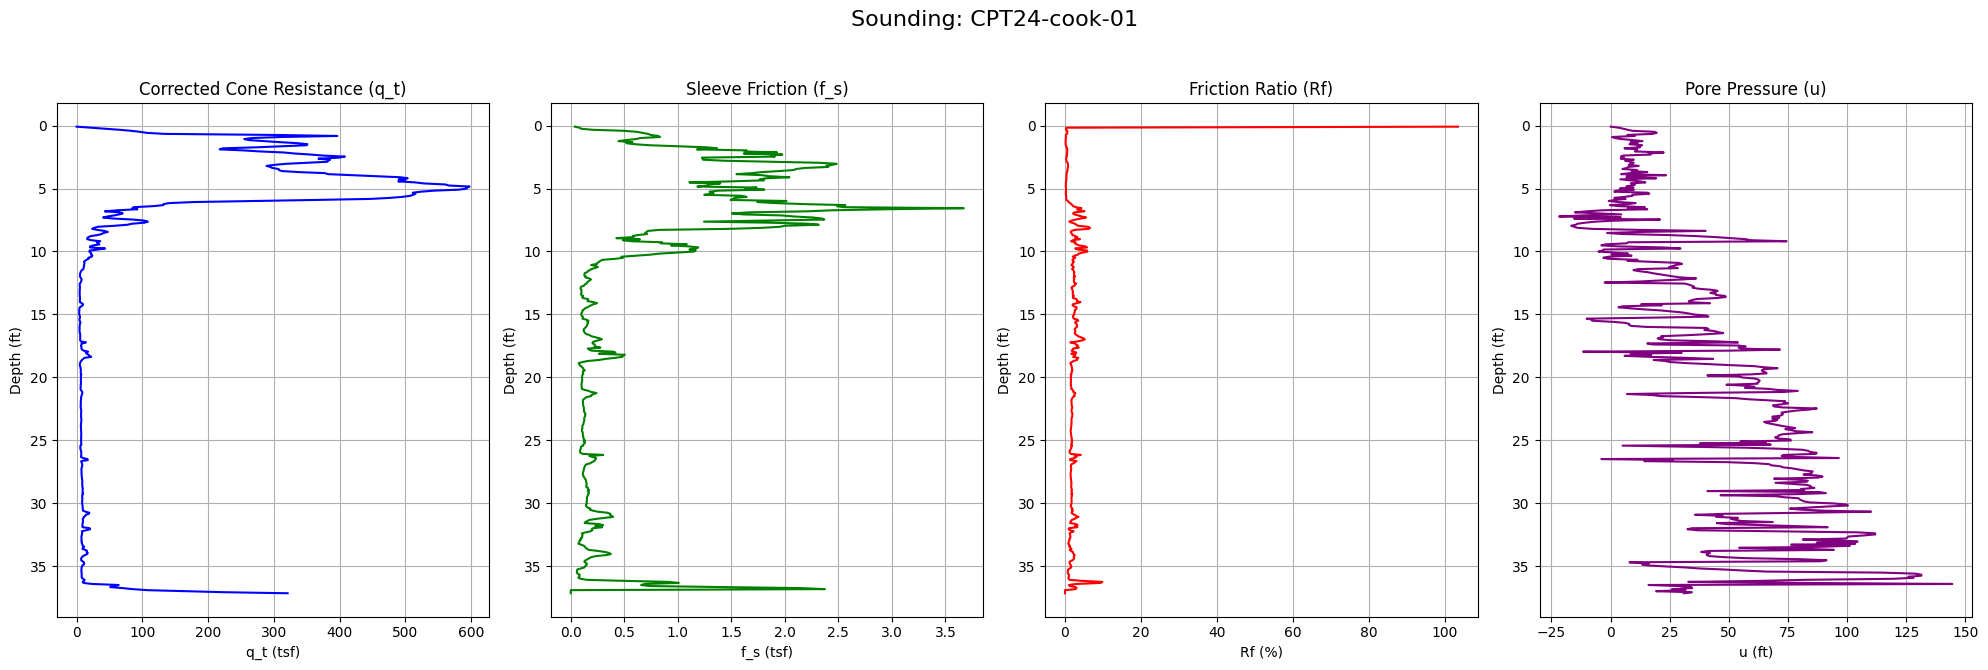

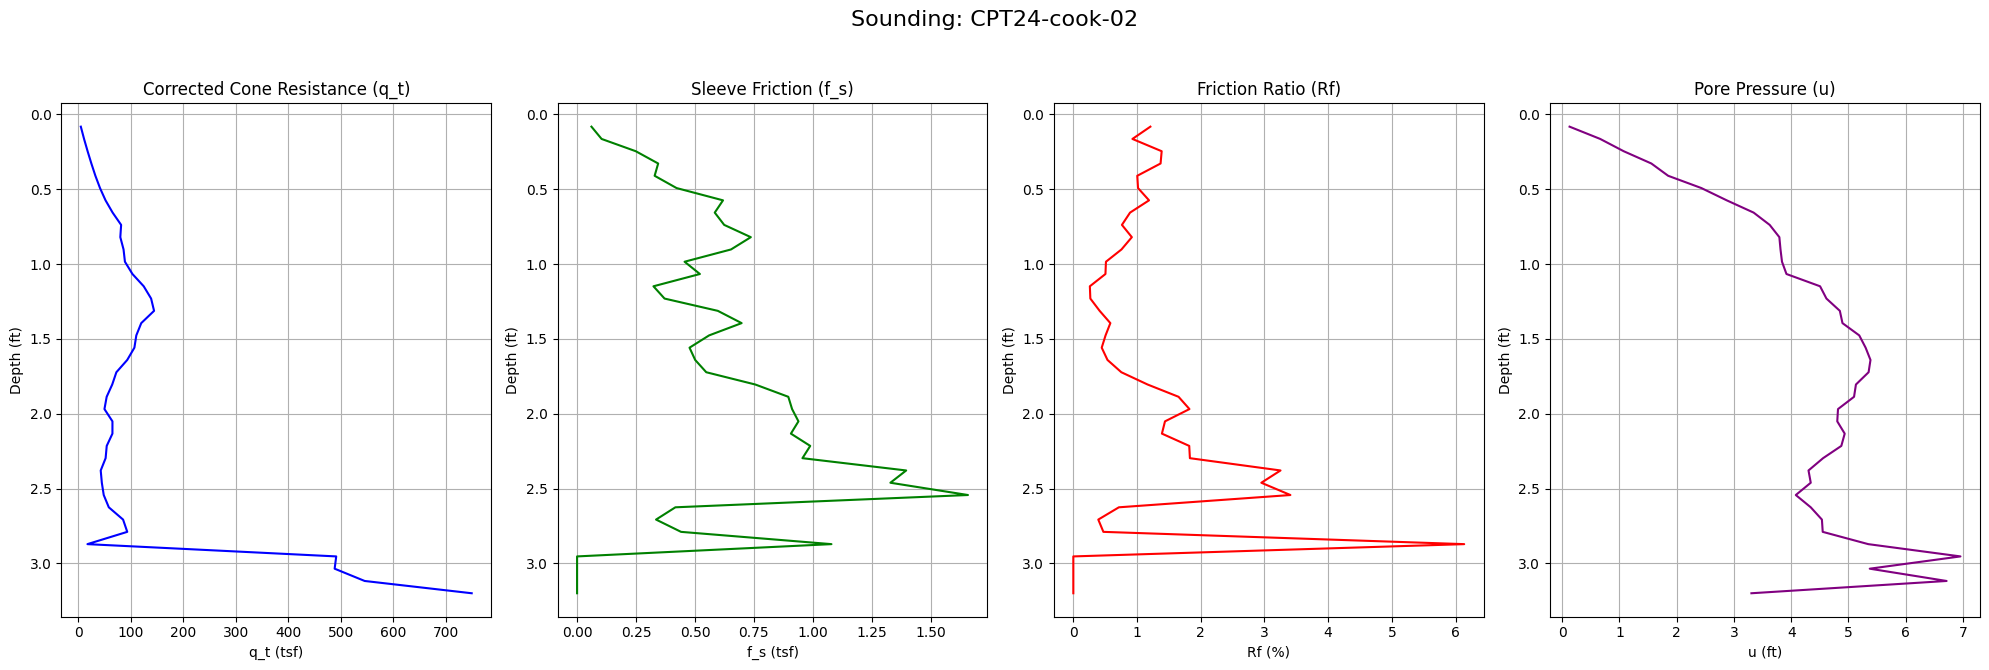

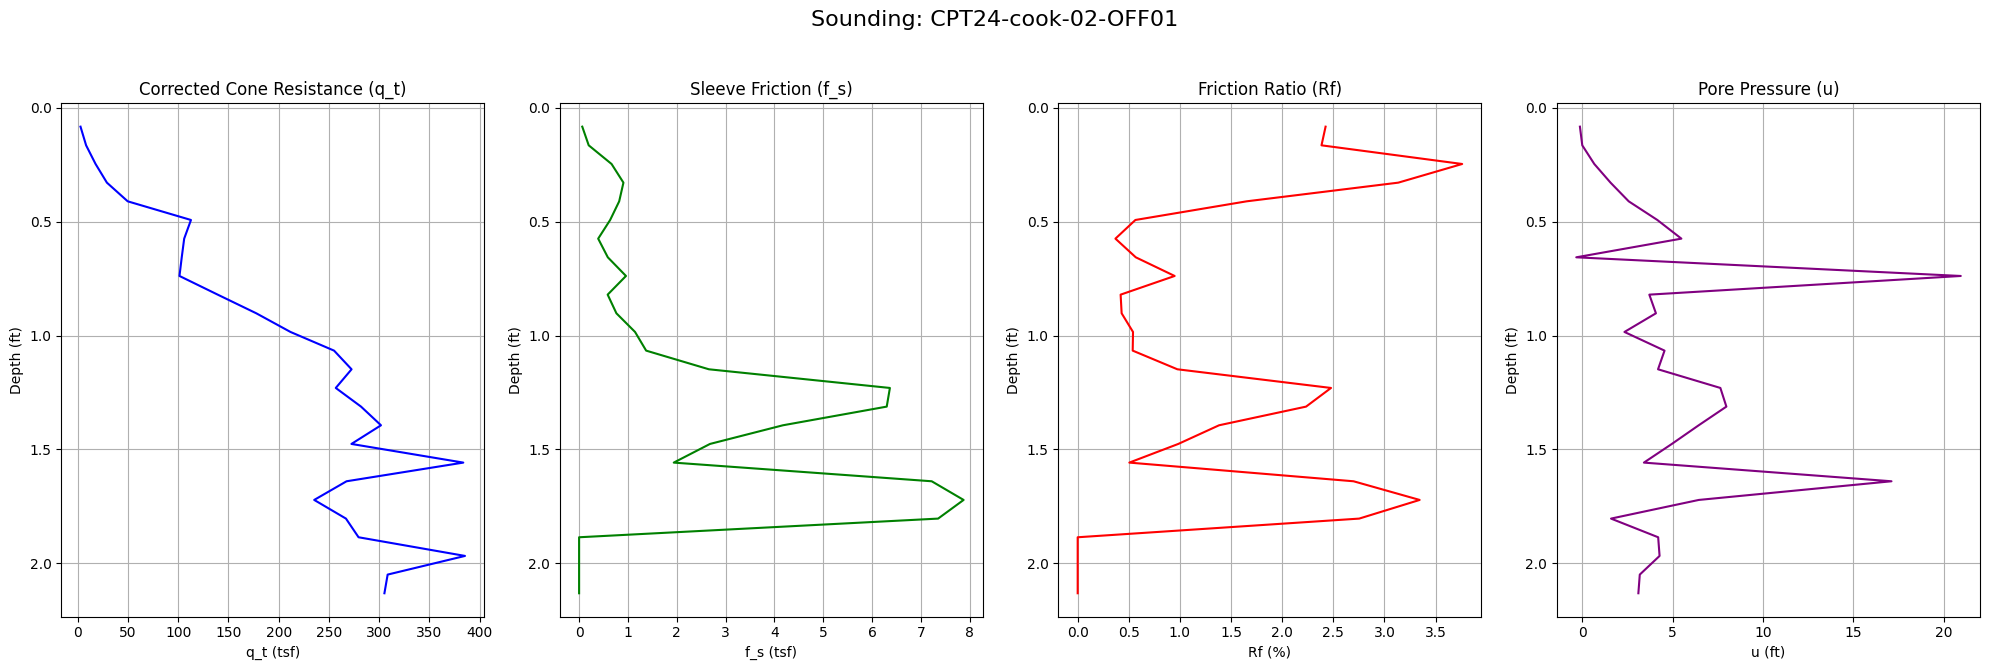

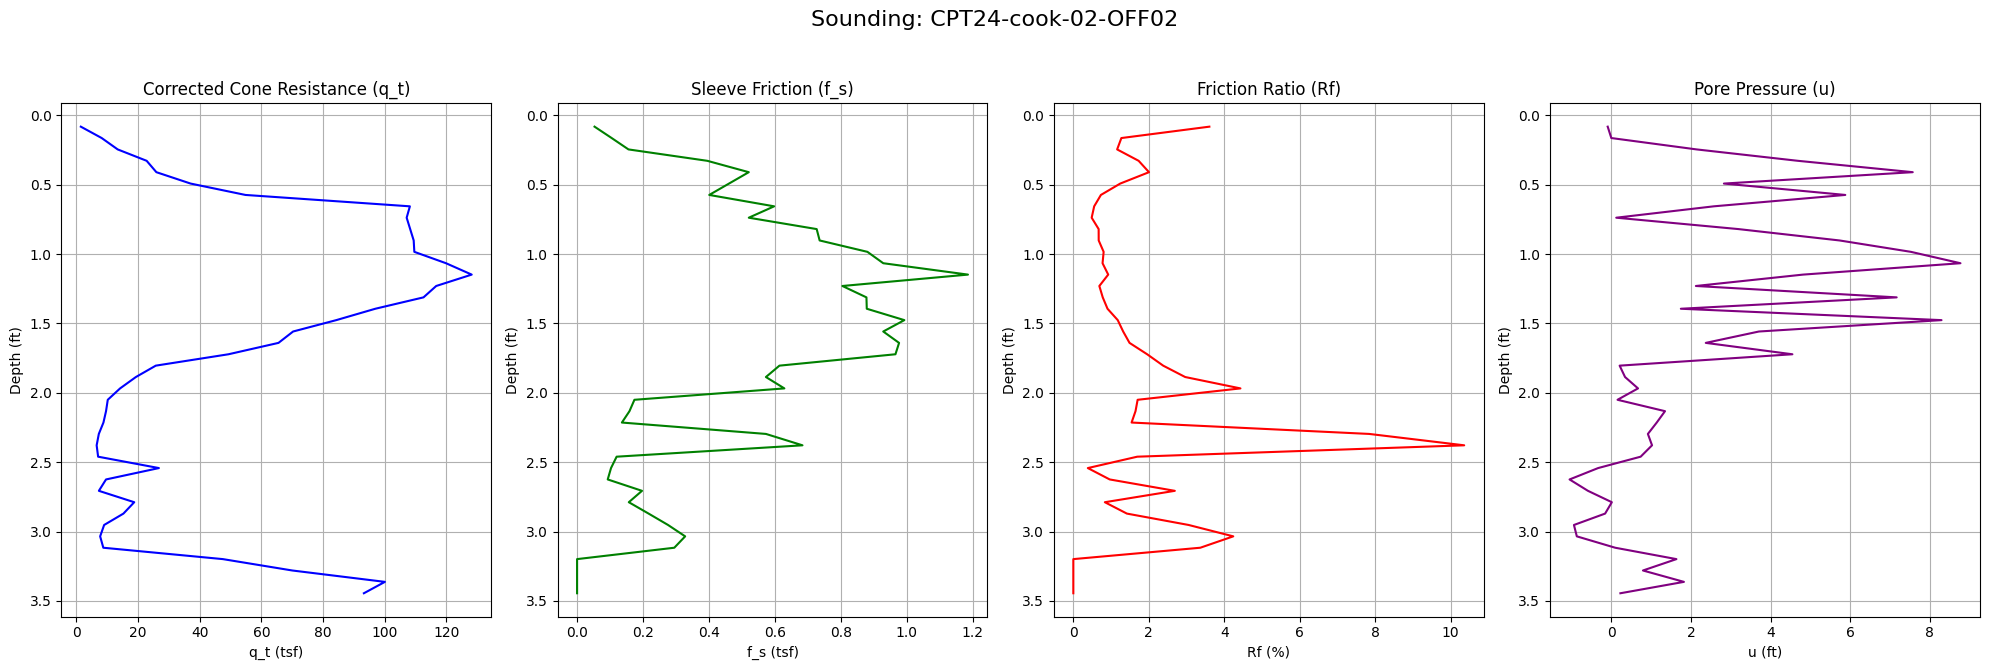

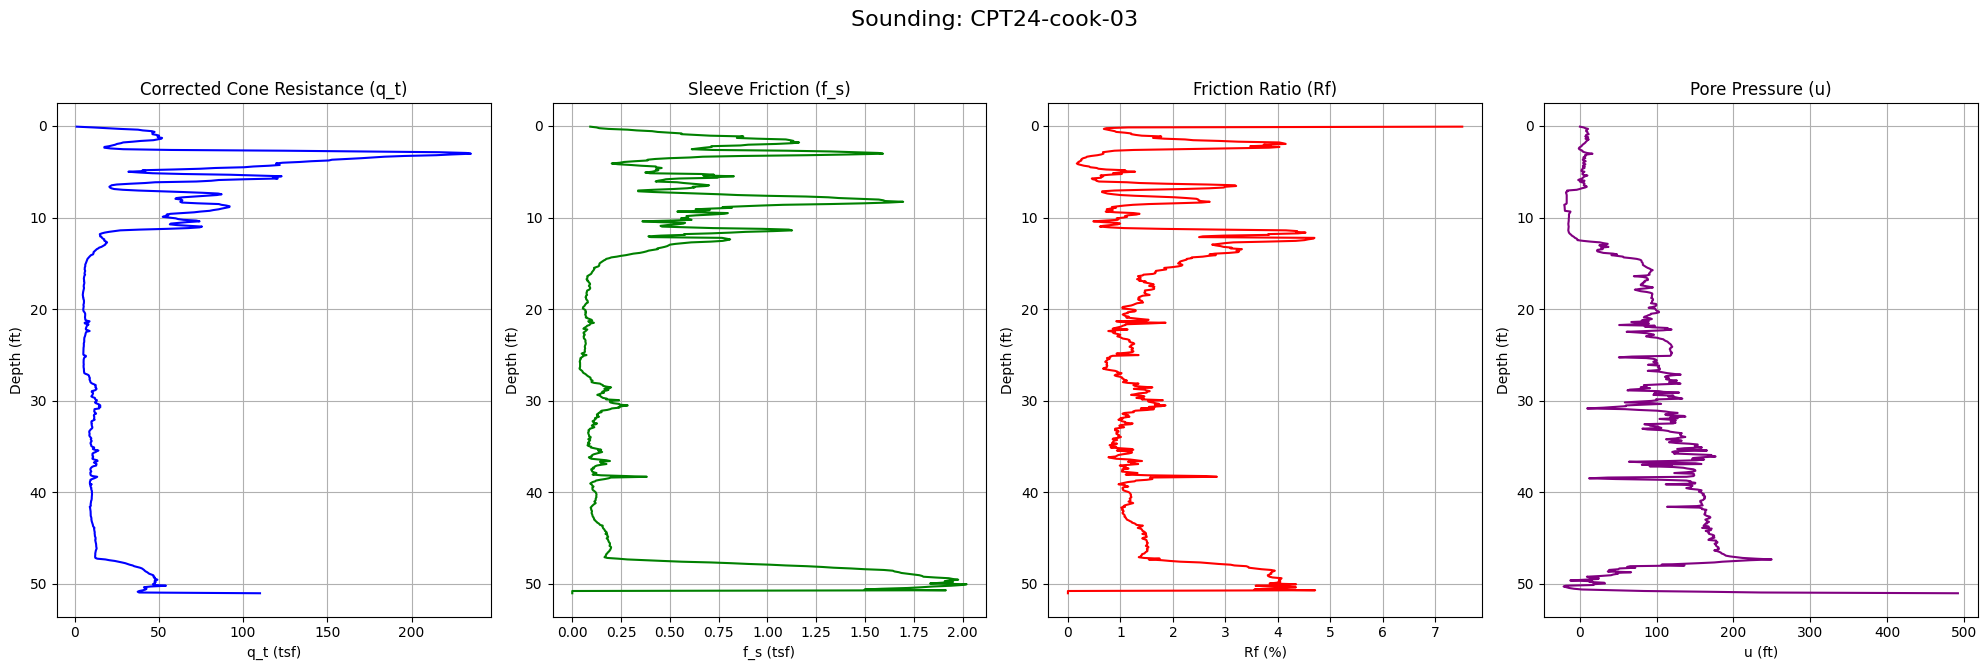

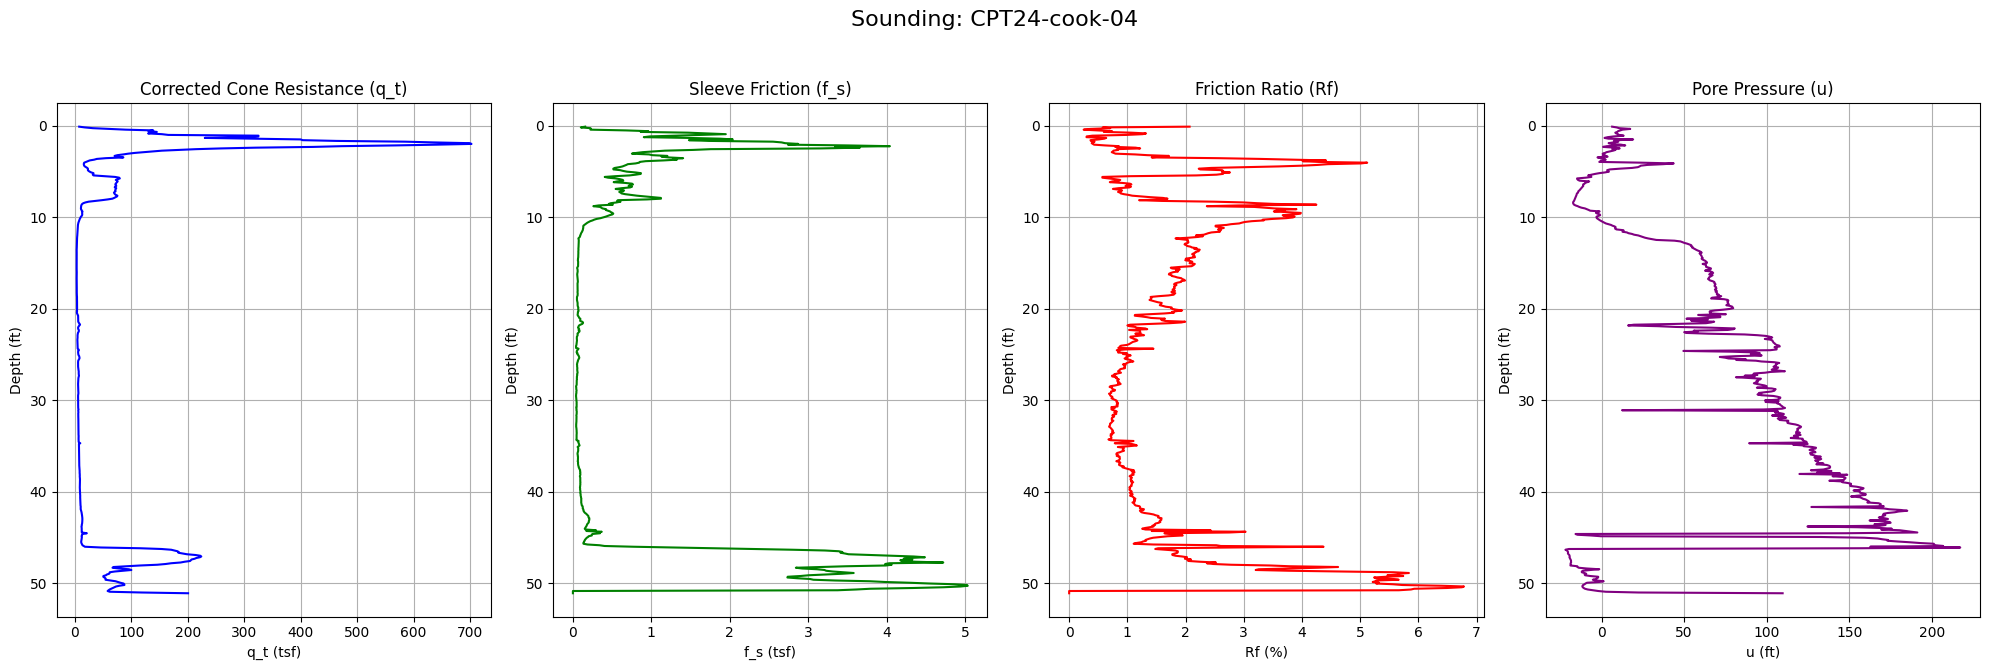

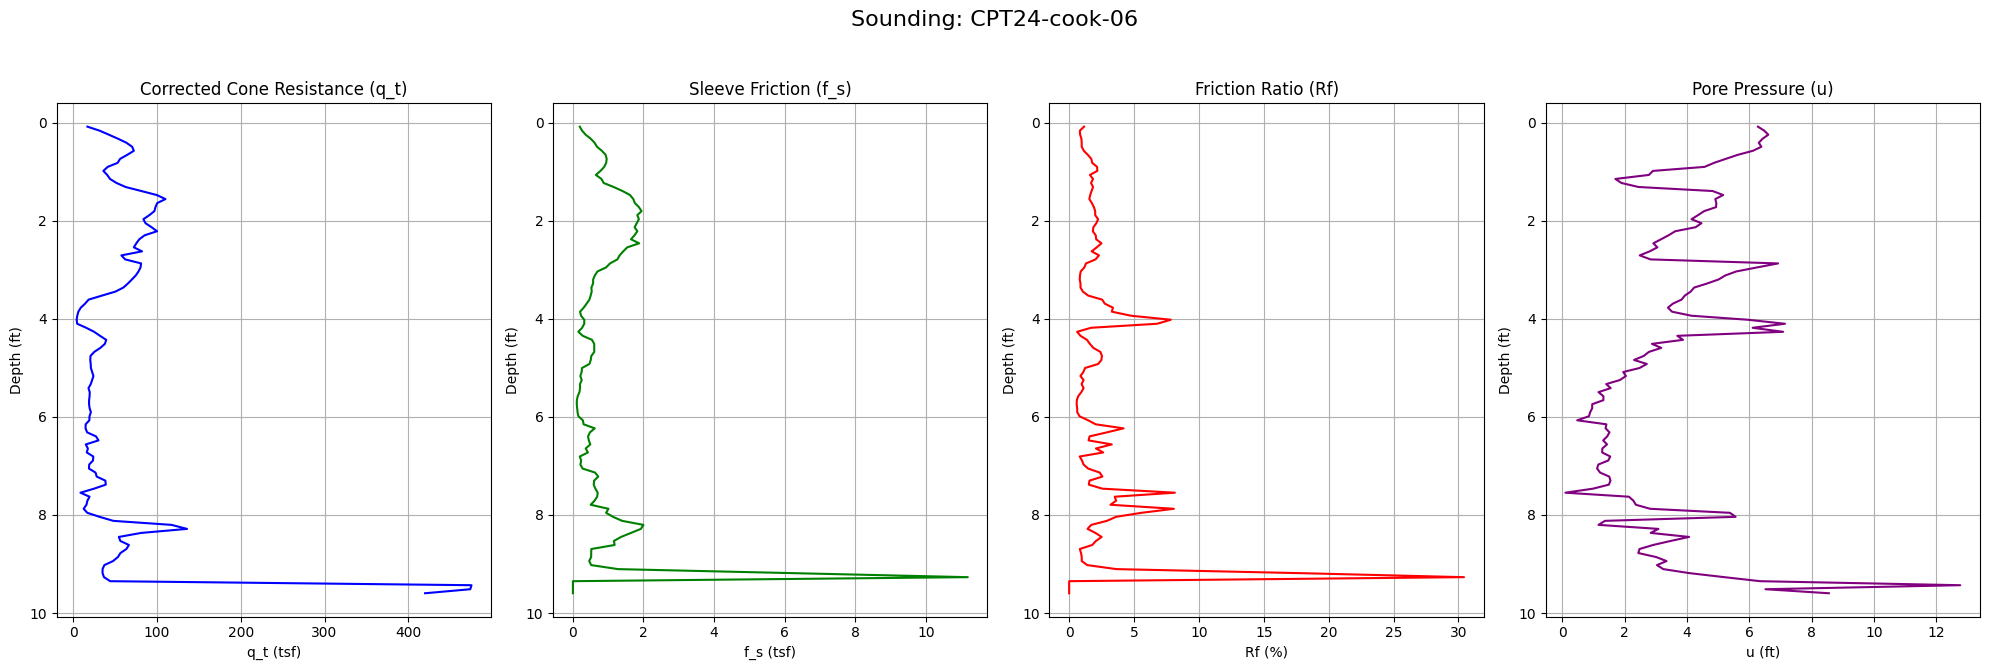

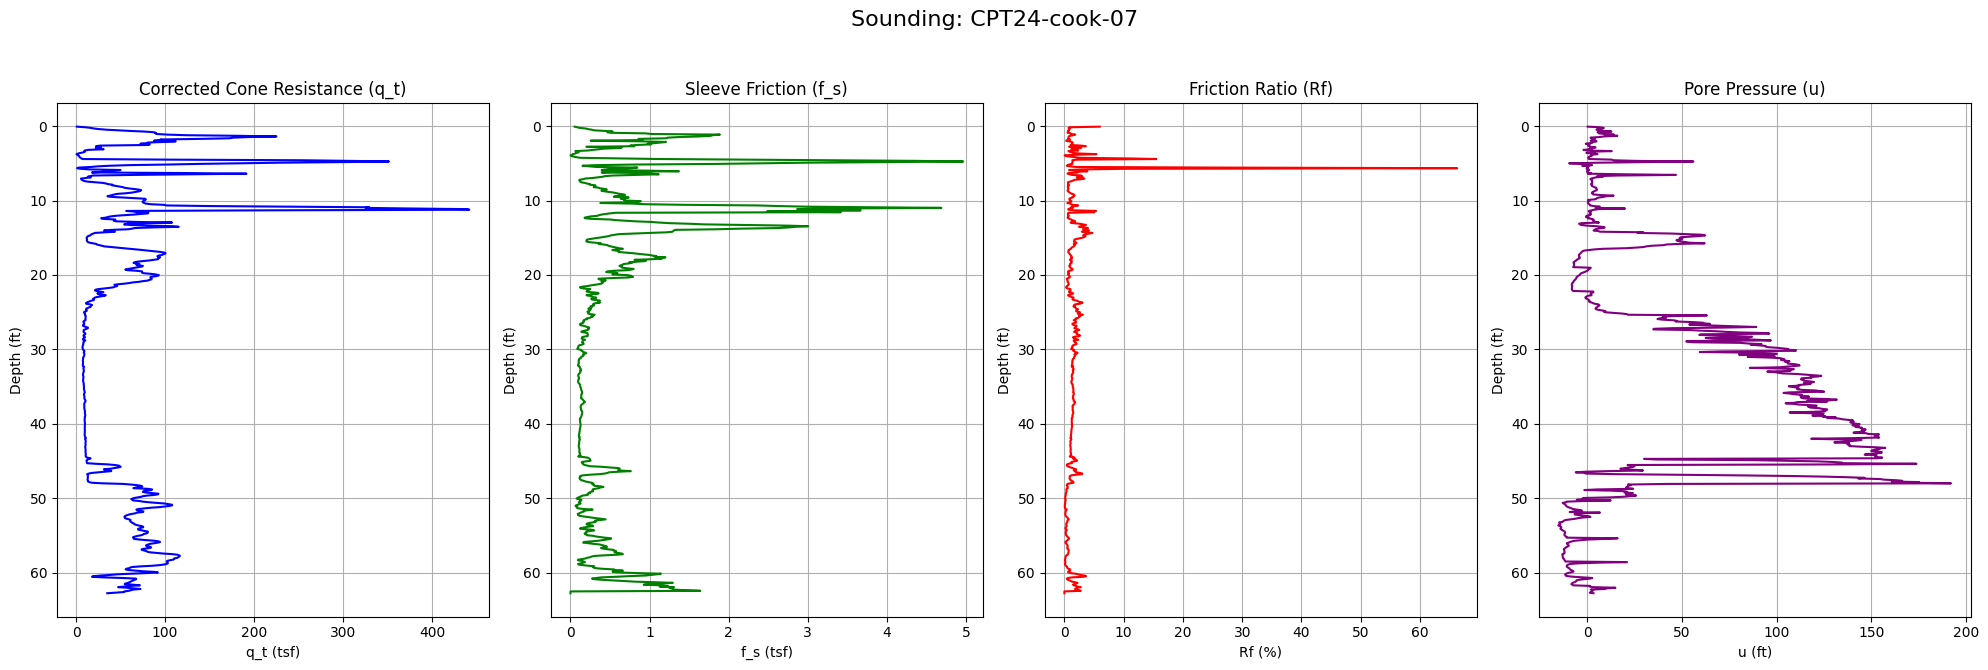

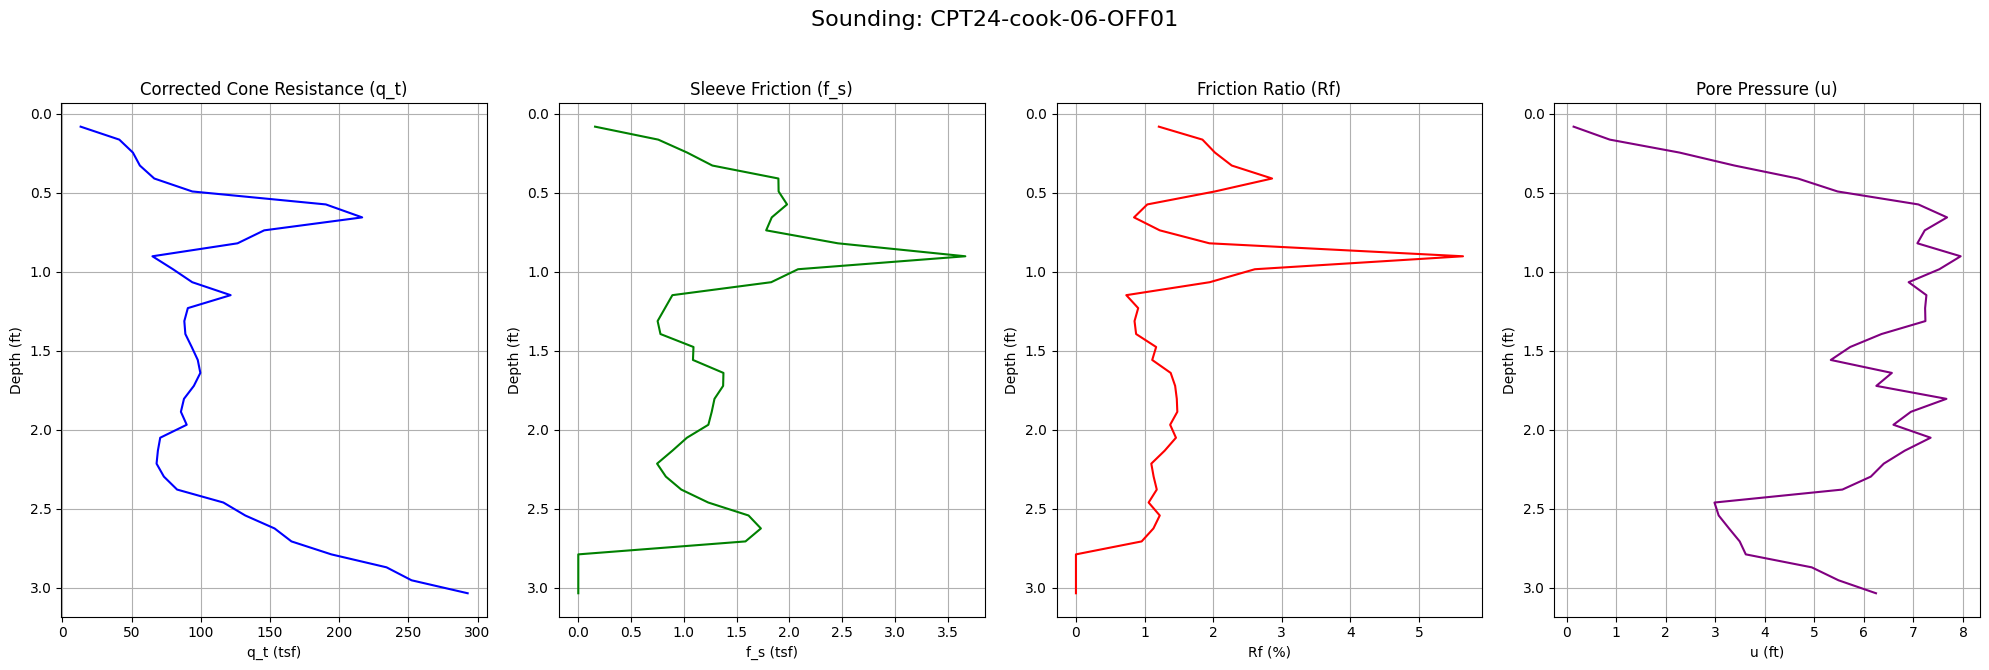

In [ ]:
unique_soundings = df_selected['Sounding'].unique()

for sounding in unique_soundings:
    df_sounding = df_selected[df_selected['Sounding'] == sounding]

    fig, axes = plt.subplots(1, 4, figsize=(20, 7)) # Changed to 1 row, 4 columns
    fig.suptitle(f'Sounding: {sounding}', fontsize=16)

    # Plot 1: q_t.tsf vs Depth.ft
    axes[0].plot(df_sounding['q_t.tsf'], df_sounding['Depth.ft'], color='blue')
    axes[0].set_ylabel('Depth (ft)')
    axes[0].set_xlabel('q_t (tsf)')
    axes[0].set_title('Corrected Cone Resistance (q_t)')
    axes[0].invert_yaxis()
    axes[0].grid(True)

    # Plot 2: f_s.tsf vs Depth.ft
    axes[1].plot(df_sounding['f_s.tsf'], df_sounding['Depth.ft'], color='green')
    axes[1].set_ylabel('Depth (ft)')
    axes[1].set_xlabel('f_s (tsf)')
    axes[1].set_title('Sleeve Friction (f_s)')
    axes[1].invert_yaxis()
    axes[1].grid(True)

    # Plot 3: Rf.% vs Depth.ft
    axes[2].plot(df_sounding['Rf.%'], df_sounding['Depth.ft'], color='red')
    axes[2].set_ylabel('Depth (ft)')
    axes[2].set_xlabel('Rf (%)')
    axes[2].set_title('Friction Ratio (Rf)')
    axes[2].invert_yaxis()
    axes[2].grid(True)

    # Plot 4: u.ft vs Depth.ft
    axes[3].plot(df_sounding['u.ft'], df_sounding['Depth.ft'], color='purple')
    axes[3].set_ylabel('Depth (ft)')
    axes[3].set_xlabel('u (ft)')
    axes[3].set_title('Pore Pressure (u)')
    axes[3].invert_yaxis()
    axes[3].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

# Define the output PDF file name
pdf_filename = 'sounding_plots.pdf'

# Create a PdfPages object
with PdfPages(pdf_filename) as pdf:
    # Iterate through each unique sounding in the selected DataFrame
    for sounding in unique_soundings:
        # Filter the DataFrame for the current sounding
        df_sounding = df_selected[df_selected['Sounding'] == sounding]

        # Create a new figure and a 1x4 subplot layout
        fig, axes = plt.subplots(1, 4, figsize=(20, 7))
        fig.suptitle(f'Sounding: {sounding}', fontsize=16)

        # Plot 1: q_t.tsf vs Depth.ft
        axes[0].plot(df_sounding['q_t.tsf'], df_sounding['Depth.ft'], color='blue')
        axes[0].set_ylabel('Depth (ft)')
        axes[0].set_xlabel('q_t (tsf)')
        axes[0].set_title('Corrected Cone Resistance (q_t)')
        axes[0].invert_yaxis()
        axes[0].grid(True)

        # Plot 2: f_s.tsf vs Depth.ft
        axes[1].plot(df_sounding['f_s.tsf'], df_sounding['Depth.ft'], color='green')
        axes[1].set_ylabel('Depth (ft)')
        axes[1].set_xlabel('f_s (tsf)')
        axes[1].set_title('Sleeve Friction (f_s)')
        axes[1].invert_yaxis()
        axes[1].grid(True)

        # Plot 3: Rf.% vs Depth.ft
        axes[2].plot(df_sounding['Rf.%'], df_sounding['Depth.ft'], color='red')
        axes[2].set_ylabel('Depth (ft)')
        axes[2].set_xlabel('Rf (%)')
        axes[2].set_title('Friction Ratio (Rf)')
        axes[2].invert_yaxis()
        axes[2].grid(True)

        # Plot 4: u.ft vs Depth.ft
        axes[3].plot(df_sounding['u.ft'], df_sounding['Depth.ft'], color='purple')
        axes[3].set_ylabel('Depth (ft)')
        axes[3].set_xlabel('u (ft)')
        axes[3].set_title('Pore Pressure (u)')
        axes[3].invert_yaxis()
        axes[3].grid(True)

        # Adjust layout to prevent titles/labels from overlapping
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap

        # Save the current figure to the PDF
        pdf.savefig(fig)
        plt.close(fig) # Close the figure to free up memory

print(f"Multi-page PDF '{pdf_filename}' generated successfully.")

# Provide a download link for the generated PDF
files.download(pdf_filename)

Multi-page PDF 'sounding_plots.pdf' generated successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>